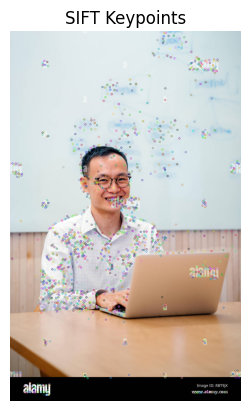

In [1]:
#1 Preprocessing
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('face1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Normalization
gray = gray / 255.0

# Noise removal (Gaussian blur)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Histogram Equalization
blur_uint8 = np.uint8(blur * 255)
equalized = cv2.equalizeHist(blur_uint8)

# SIFT Feature Extraction
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(equalized, None)

# Draw keypoints
img_kp = cv2.drawKeypoints(img, keypoints, None)

# Display
plt.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
plt.title("SIFT Keypoints")
plt.axis('off')
plt.show()

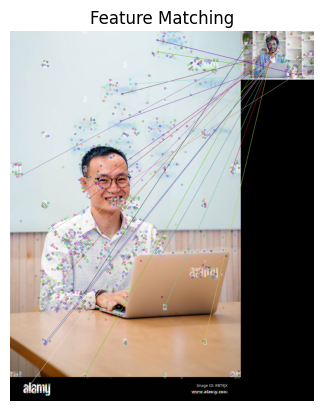

In [4]:
# Load second image
img2 = cv2.imread('face2.jpg')
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# SIFT features
kp1, des1 = sift.detectAndCompute(equalized, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# Brute Force Matcher
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

# Lowe's ratio test
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

# Draw matches
img_match = cv2.drawMatches(img, kp1, img2, kp2, good_matches, None)

plt.imshow(cv2.cvtColor(img_match, cv2.COLOR_BGR2RGB))
plt.title("Feature Matching")
plt.axis('off')
plt.show()